<a href="https://www.kaggle.com/code/omborse771924/global-healthcare-pharma-2010-2026-eda?scriptVersionId=330623356" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/clinical_trials.csv
/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/biotech_funding.csv
/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/pharma_companies_financials.csv
/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/drug_approvals.csv
/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/disease_burden.csv


## Loading Dataset

In [2]:
import pandas as pd

clinical_trials = pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/clinical_trials.csv")

biotech_funding = pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/biotech_funding.csv")

pharma_financials = pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/pharma_companies_financials.csv")

drug_approvals = pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/drug_approvals.csv")

disease_burden = pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/disease_burden.csv")

In [3]:
datasets = {
    "Clinical Trials": clinical_trials,
    "Biotech Funding": biotech_funding,
    "Pharma Financials": pharma_financials,
    "Drug Approvals": drug_approvals,
    "Disease Burden": disease_burden
}

for name, df in datasets.items():

    print("="*70)
    print(name)
    print("="*70)

    display(df.head())

    print("\nShape")
    print(df.shape)

    print("\nColumns")
    print(df.columns)

    print("\nInformation")
    print(df.info())

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate Rows")
    print(df.duplicated().sum())

    print("\nDescribe")
    display(df.describe(include="all"))

Clinical Trials


,trial_id,completion_date,year,sponsor,therapy_area,phase,enrollment_n,duration_months,outcome,is_success,is_failure,estimated_stock_impact_pct
0,NCT00000024,2010-01-05,2010,BioNTech,neurology,Phase 2,186,11,Met primary endpoint,1,0,6.0
1,NCT00000015,2010-02-15,2010,Pfizer,metabolic,Phase 2,181,29,Mixed results,0,0,-0.7
2,NCT00000013,2010-02-27,2010,GSK,oncology,Phase 2,115,13,Failed primary endpoint,0,1,-33.2
3,NCT00000022,2010-03-02,2010,Takeda,infectious,Phase 2,359,15,Met primary endpoint,1,0,12.4
4,NCT00000019,2010-04-09,2010,Novo Nordisk,oncology,Phase 3,840,42,Failed primary endpoint,0,1,-14.7



Shape
(599, 12)

Columns
Index(['trial_id', 'completion_date', 'year', 'sponsor', 'therapy_area',
       'phase', 'enrollment_n', 'duration_months', 'outcome', 'is_success',
       'is_failure', 'estimated_stock_impact_pct'],
      dtype='object')

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trial_id                    599 non-null    object 
 1   completion_date             599 non-null    object 
 2   year                        599 non-null    int64  
 3   sponsor                     599 non-null    object 
 4   therapy_area                599 non-null    object 
 5   phase                       599 non-null    object 
 6   enrollment_n                599 non-null    int64  
 7   duration_months             599 non-null    int64  
 8   outcome                     599 non-null    object 
 9   i

,trial_id,completion_date,year,sponsor,therapy_area,phase,enrollment_n,duration_months,outcome,is_success,is_failure,estimated_stock_impact_pct
count,599,599,599.000000,599,599,599,599.000000,599.000000,599,599.000000,599.000000,599.000000
unique,599,574,NaN,21,10,2,NaN,NaN,3,NaN,NaN,NaN
top,NCT00000024,2017-04-01,NaN,Pfizer,oncology,Phase 3,NaN,NaN,Met primary endpoint,NaN,NaN,NaN
freq,1,2,NaN,40,180,326,NaN,NaN,312,NaN,NaN,NaN
mean,NaN,NaN,2017.612688,NaN,NaN,NaN,790.163606,27.555927,NaN,0.520868,0.325543,-0.961436
std,NaN,NaN,4.759807,NaN,NaN,NaN,720.689342,10.885531,NaN,0.499982,0.468969,12.063116
min,NaN,NaN,2010.000000,NaN,NaN,NaN,47.000000,6.000000,NaN,0.000000,0.000000,-41.200000
25%,NaN,NaN,2013.000000,NaN,NaN,NaN,244.500000,18.000000,NaN,0.000000,0.000000,-8.550000
50%,NaN,NaN,2018.000000,NaN,NaN,NaN,524.000000,29.000000,NaN,1.000000,0.000000,1.200000
75%,NaN,NaN,2022.000000,NaN,NaN,NaN,1112.000000,36.000000,NaN,1.000000,1.000000,8.200000


Biotech Funding


...

,approval_id,approval_date,year,drug_name,sponsor_company,drug_type,therapy_area,peak_sales_usd_bn_est,is_blockbuster,is_mega_blockbuster,description,is_real_headline
count,722,722,722.000000,722,722,722,722,722.000000,722.000000,722.000000,722,722.000000
unique,722,669,NaN,685,49,5,12,NaN,NaN,NaN,94,NaN
top,APP0062,2021-07-22,NaN,Ilenev-nib,Amgen,small_mol,oncology,NaN,NaN,NaN,FDA approval — oncology small_mol,NaN
freq,1,3,NaN,3,31,403,276,NaN,NaN,NaN,152,NaN
mean,NaN,NaN,2018.400277,NaN,NaN,NaN,NaN,1.173850,0.211911,0.058172,NaN,0.060942
std,NaN,NaN,4.442782,NaN,NaN,NaN,NaN,3.130775,0.408946,0.234230,NaN,0.239389
min,NaN,NaN,2010.000000,NaN,NaN,NaN,NaN,0.010000,0.000000,0.000000,NaN,0.000000
25%,NaN,NaN,2015.000000,NaN,NaN,NaN,NaN,0.070000,0.000000,0.000000,NaN,0.000000
50%,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN,0.230000,0.000000,0.000000,NaN,0.000000
75%,NaN,NaN,2022.000000,NaN,NaN,NaN,NaN,0.767500,0.000000,0.000000,NaN,0.000000


Disease Burden


,year,region,disease,dalys_millions,global_dalys_millions
0,2010,North America,Cardiovascular disease,18.49,350.0
1,2010,Western Europe,Cardiovascular disease,20.94,350.0
2,2010,Eastern Europe,Cardiovascular disease,13.05,350.0
3,2010,China,Cardiovascular disease,60.71,350.0
4,2010,India,Cardiovascular disease,66.51,350.0



Shape
(3310, 5)

Columns
Index(['year', 'region', 'disease', 'dalys_millions', 'global_dalys_millions'], dtype='object')

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3310 entries, 0 to 3309
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   3310 non-null   int64  
 1   region                 3310 non-null   object 
 2   disease                3310 non-null   object 
 3   dalys_millions         3310 non-null   float64
 4   global_dalys_millions  3310 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 129.4+ KB
None

Missing Values
year                     0
region                   0
disease                  0
dalys_millions           0
global_dalys_millions    0
dtype: int64

Duplicate Rows
0

Describe


,year,region,disease,dalys_millions,global_dalys_millions
count,3310.000000,3310,3310,3310.000000,3310.000000
unique,NaN,10,20,NaN,NaN
top,NaN,North America,Cardiovascular disease,NaN,NaN
freq,NaN,331,170,NaN,NaN
mean,2018.108761,NaN,NaN,11.068704,108.925982
std,4.902212,NaN,NaN,13.754323,95.351576
min,2010.000000,NaN,NaN,0.100000,0.000000
25%,2014.000000,NaN,NaN,2.640000,43.000000
50%,2018.000000,NaN,NaN,6.280000,73.500000
75%,2022.000000,NaN,NaN,13.907500,149.000000


In [4]:
import pandas as pd

clinical_trials = pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/clinical_trials.csv")
biotech_funding = pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/biotech_funding.csv")
pharma_financials = pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/pharma_companies_financials.csv")
drug_approvals = pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/drug_approvals.csv")
disease_burden = pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/disease_burden.csv")

print("Clinical Trials")
print(clinical_trials.columns.tolist())

print("\nBiotech Funding")
print(biotech_funding.columns.tolist())

print("\nPharma Financials")
print(pharma_financials.columns.tolist())

print("\nDrug Approvals")
print(drug_approvals.columns.tolist())

print("\nDisease Burden")
print(disease_burden.columns.tolist())

Clinical Trials
['trial_id', 'completion_date', 'year', 'sponsor', 'therapy_area', 'phase', 'enrollment_n', 'duration_months', 'outcome', 'is_success', 'is_failure', 'estimated_stock_impact_pct']

Biotech Funding
['deal_id', 'date', 'year', 'deal_type', 'acquirer_or_investors', 'target_or_company', 'value_usd_bn', 'description', 'is_megadeal', 'is_real_headline']

Pharma Financials
['year', 'company_name', 'ticker', 'country_iso3', 'segment', 'revenue_usd_bn', 'operating_margin_pct', 'operating_income_usd_bn', 'rd_spend_usd_bn', 'pipeline_size_est']

Drug Approvals
['approval_id', 'approval_date', 'year', 'drug_name', 'sponsor_company', 'drug_type', 'therapy_area', 'peak_sales_usd_bn_est', 'is_blockbuster', 'is_mega_blockbuster', 'description', 'is_real_headline']

Disease Burden
['year', 'region', 'disease', 'dalys_millions', 'global_dalys_millions']


## EDA

,trial_id,completion_date,year,sponsor,therapy_area,phase,enrollment_n,duration_months,outcome,is_success,is_failure,estimated_stock_impact_pct
0,NCT00000024,2010-01-05,2010,BioNTech,neurology,Phase 2,186,11,Met primary endpoint,1,0,6.0
1,NCT00000015,2010-02-15,2010,Pfizer,metabolic,Phase 2,181,29,Mixed results,0,0,-0.7
2,NCT00000013,2010-02-27,2010,GSK,oncology,Phase 2,115,13,Failed primary endpoint,0,1,-33.2
3,NCT00000022,2010-03-02,2010,Takeda,infectious,Phase 2,359,15,Met primary endpoint,1,0,12.4
4,NCT00000019,2010-04-09,2010,Novo Nordisk,oncology,Phase 3,840,42,Failed primary endpoint,0,1,-14.7


(599, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trial_id                    599 non-null    object 
 1   completion_date             599 non-null    object 
 2   year                        599 non-null    int64  
 3   sponsor                     599 non-null    object 
 4   therapy_area                599 non-null    object 
 5   phase                       599 non-null    object 
 6   enrollment_n                599 non-null    int64  
 7   duration_months             599 non-null    int64  
 8   outcome                     599 non-null    object 
 9   is_success                  599 non-null    int64  
 10  is_failure                  599 non-null    int64  
 11  estimated_stock_impact_pct  599 non-null    float64
dtypes: float64(1), int64(5), object(6)
memory usage: 56.3+ KB
None


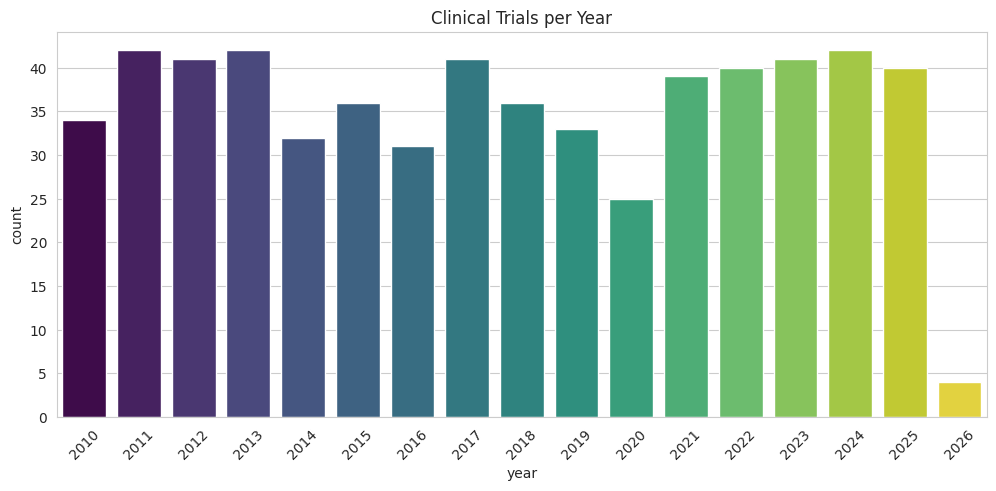

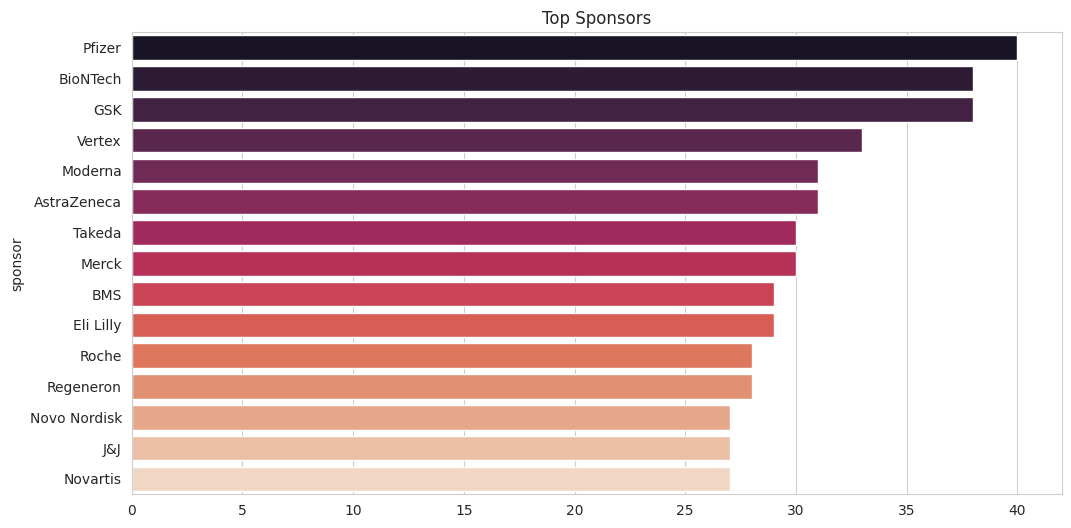

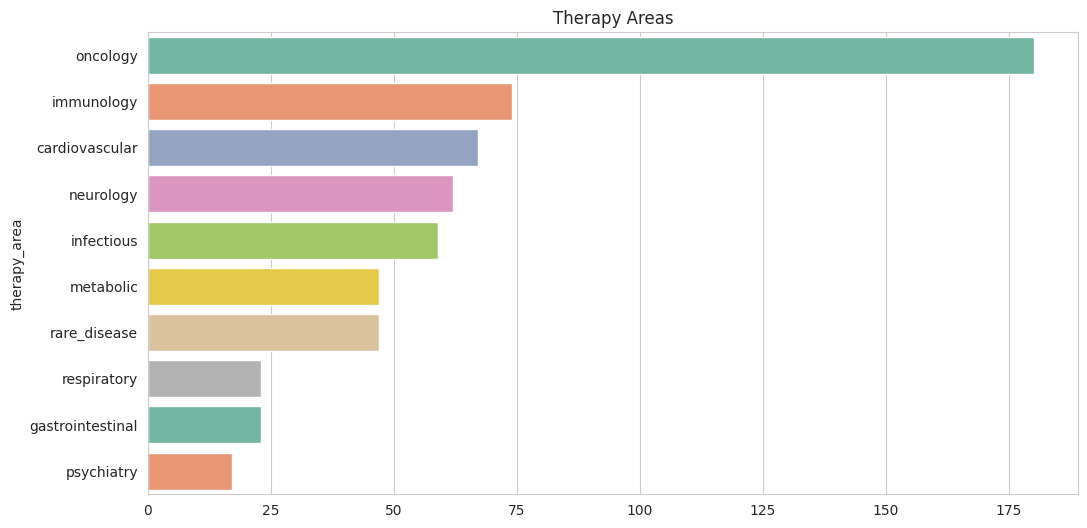

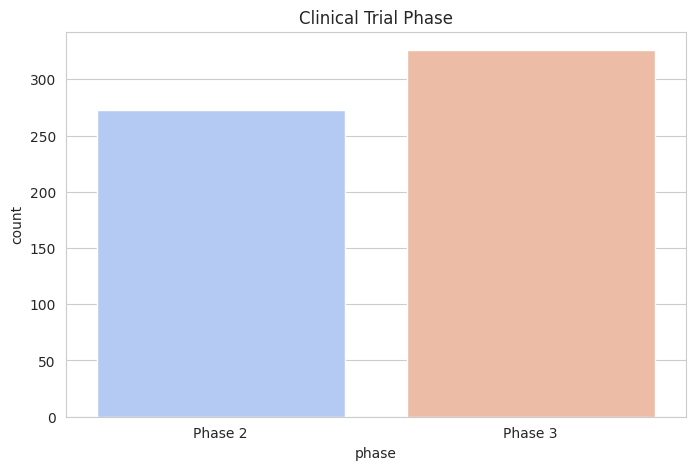

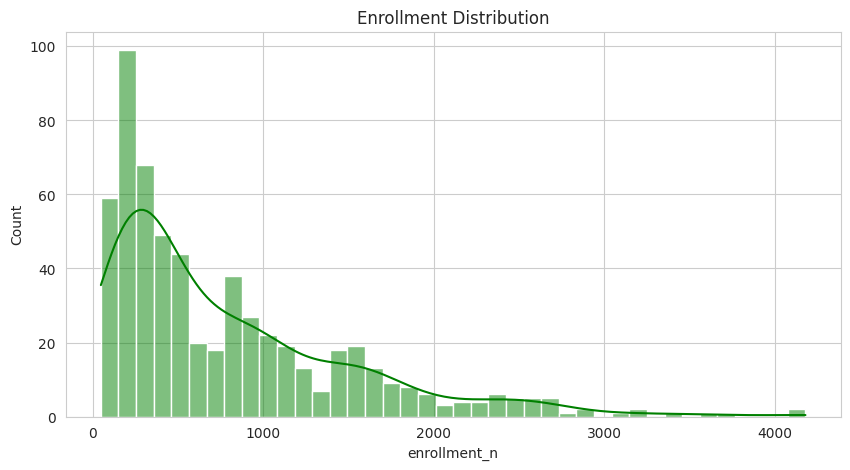

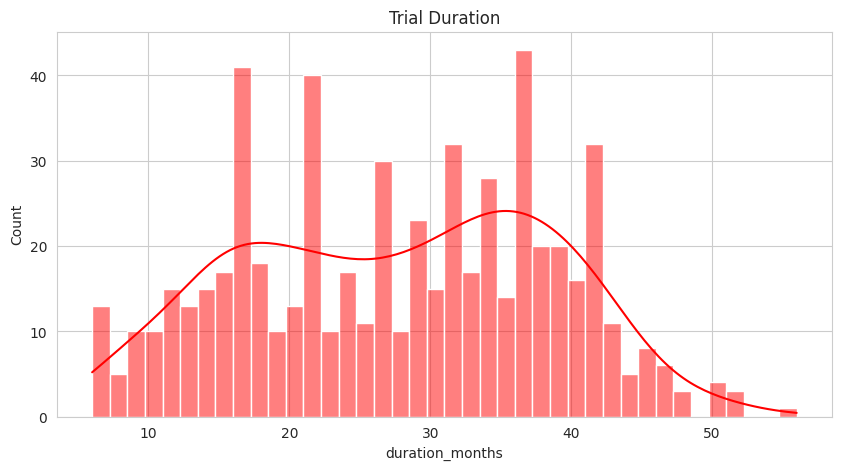

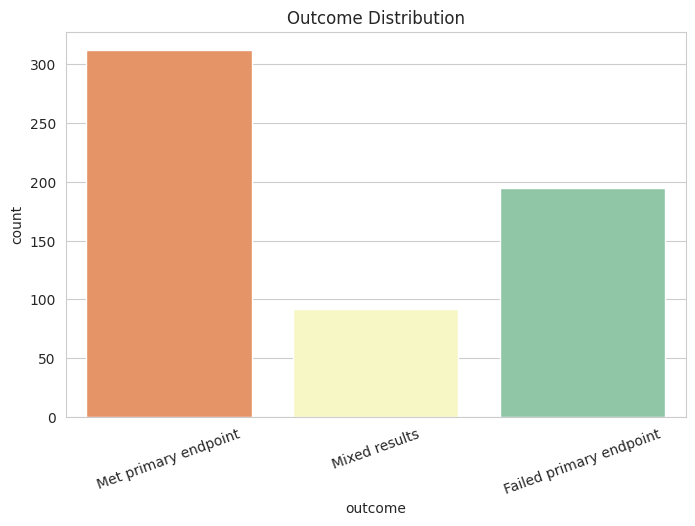

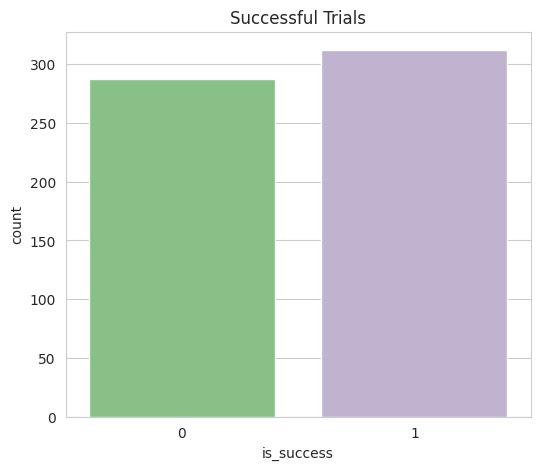

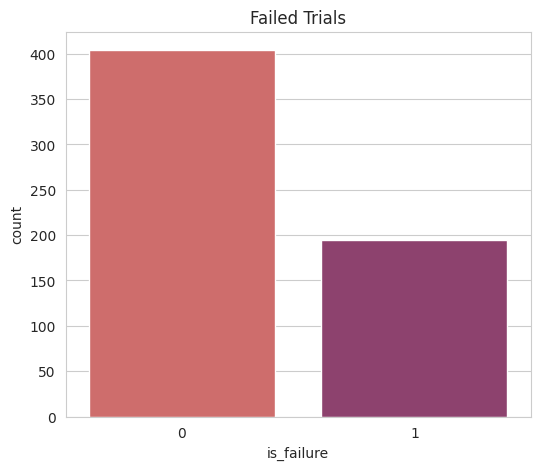

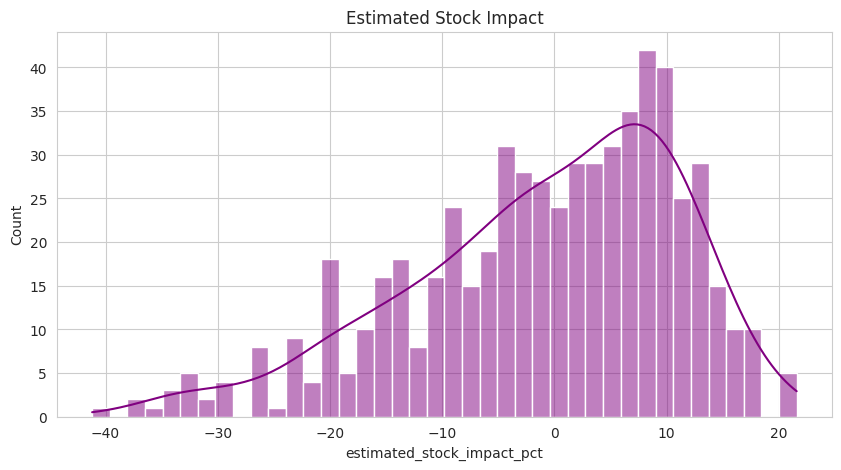

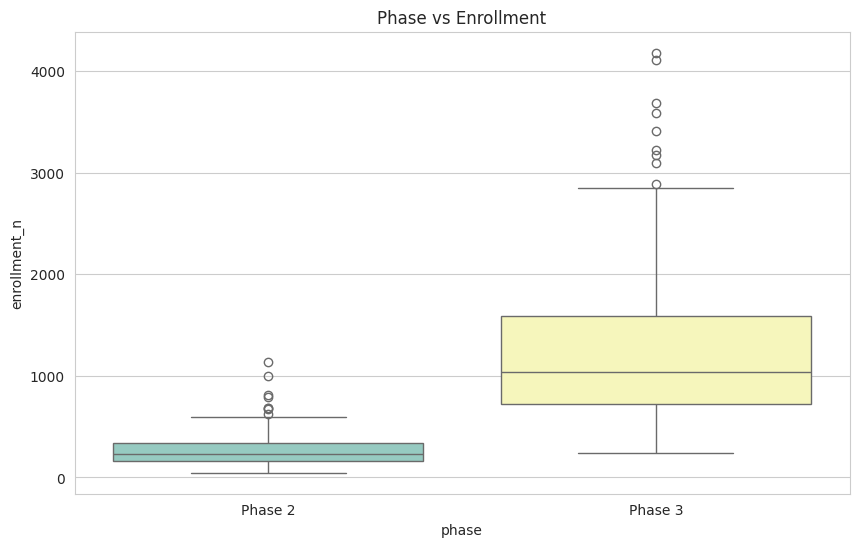

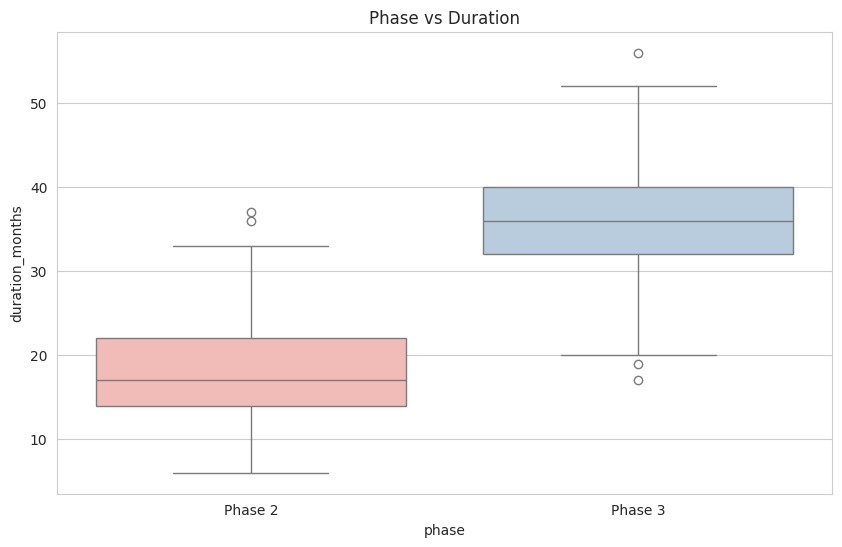

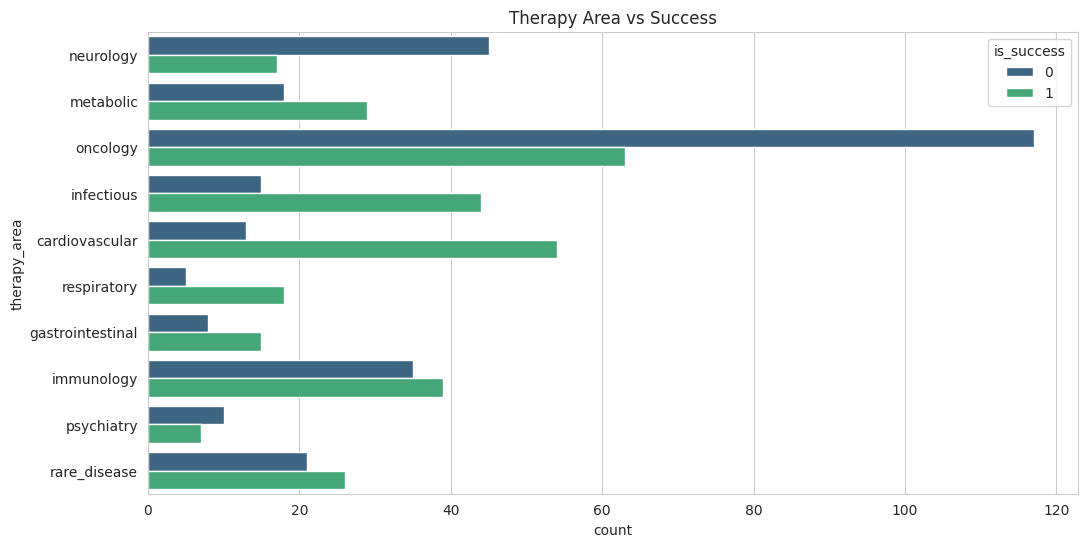

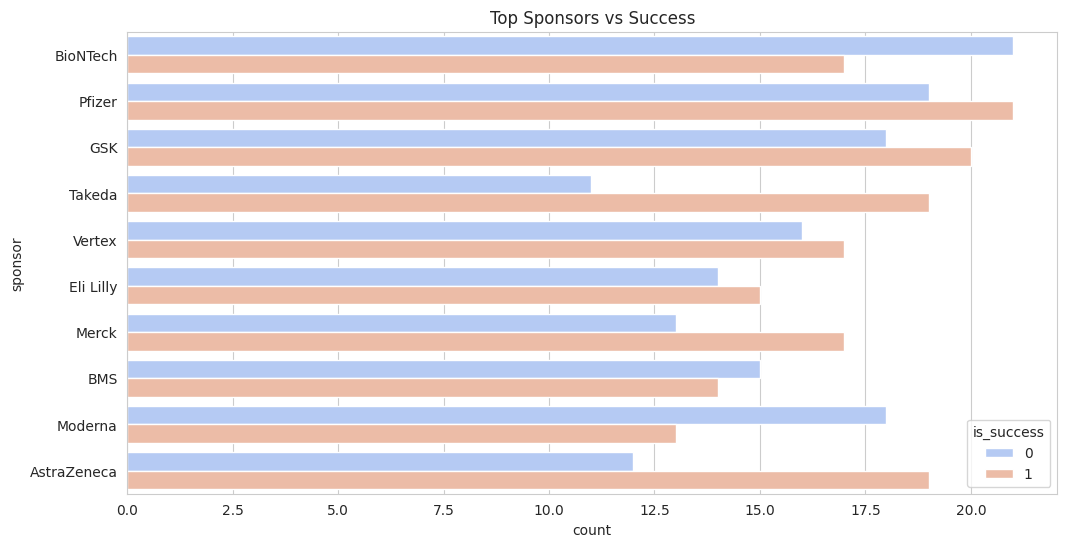

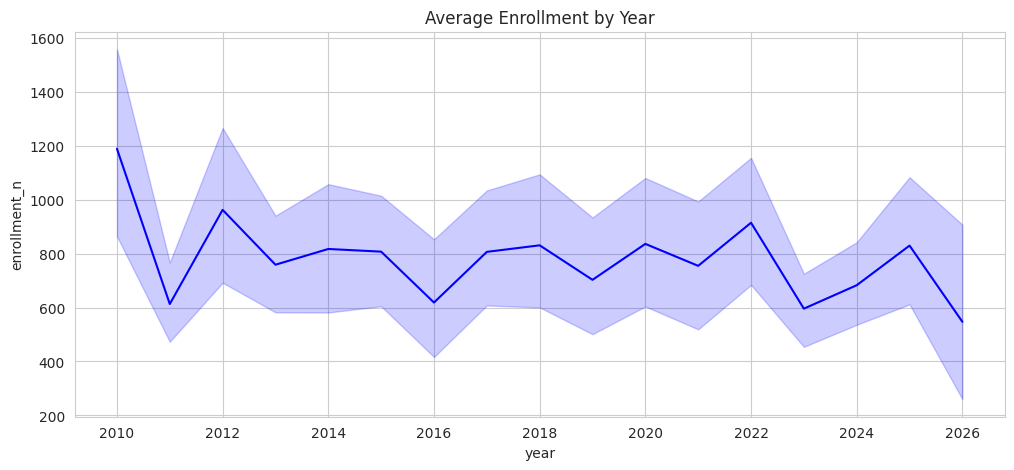

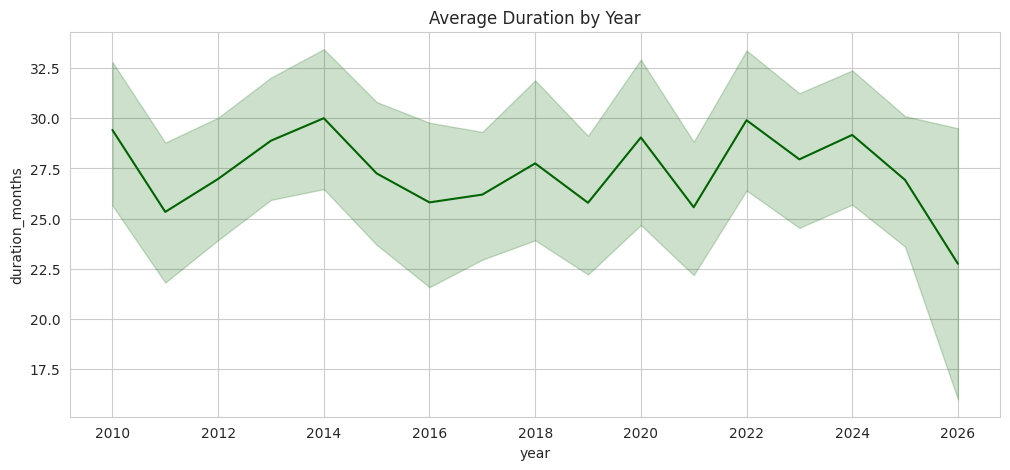

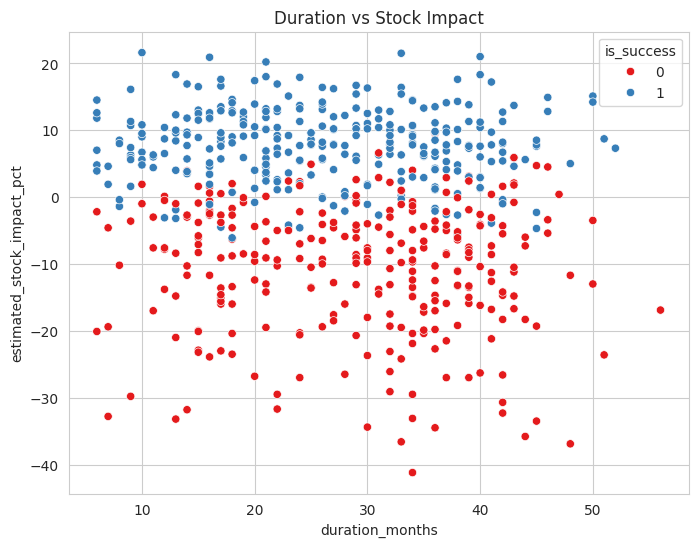

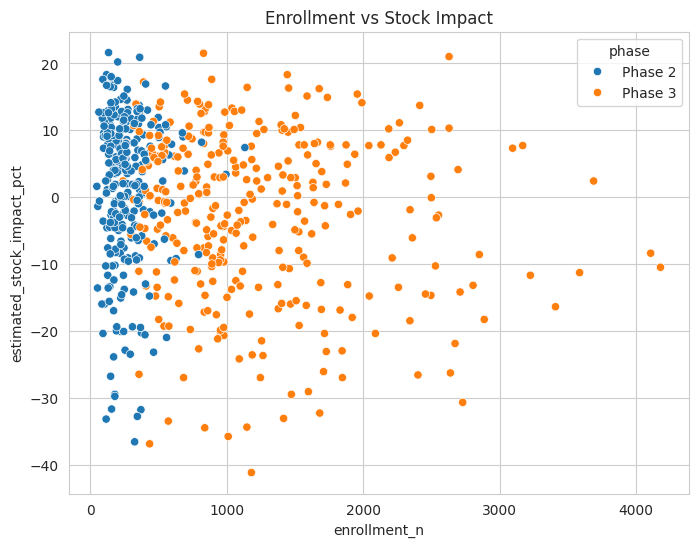

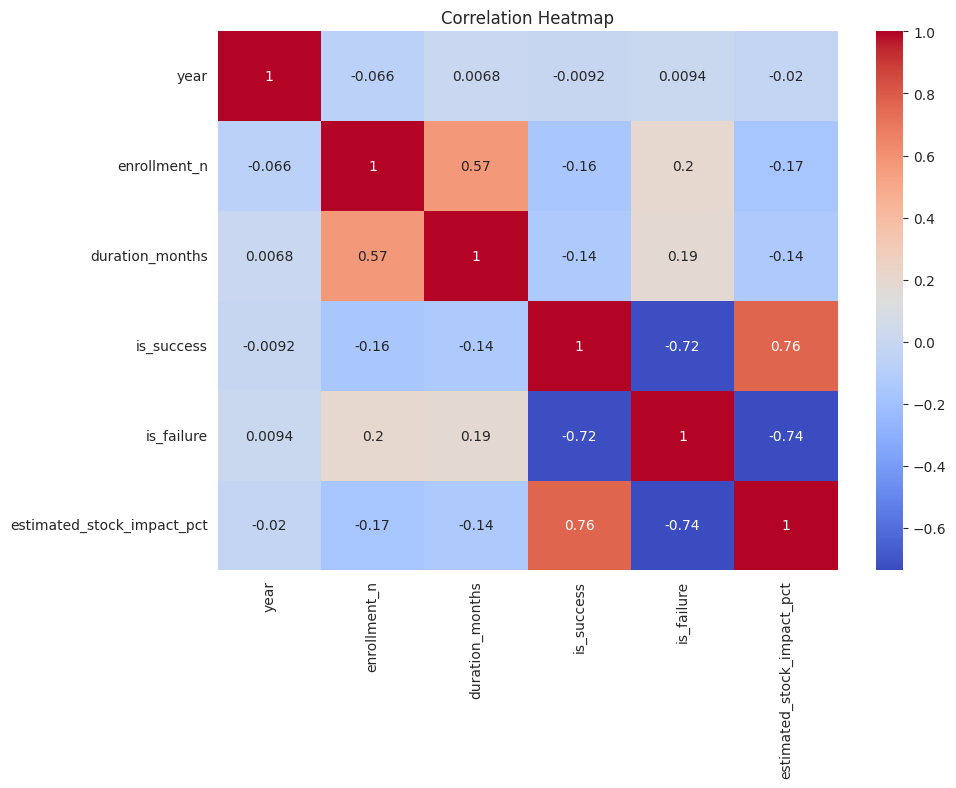

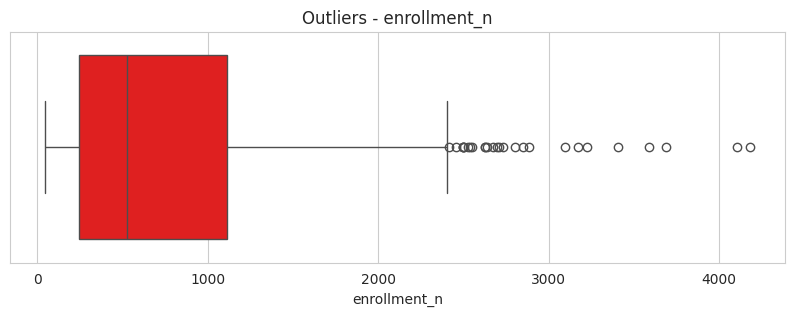

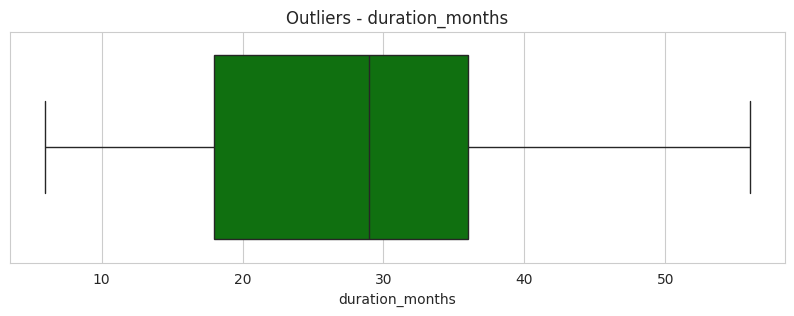

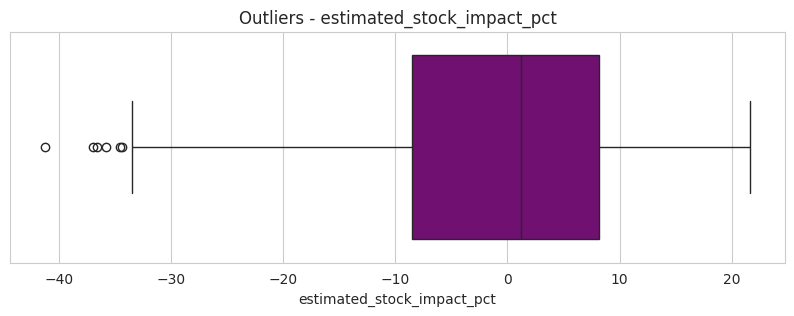

Clinical Trials EDA Completed Successfully


In [5]:
sns.set_style("whitegrid")

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv("/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/clinical_trials.csv")

display(df.head())

print(df.shape)
print(df.info())

# Convert date
df["completion_date"] = pd.to_datetime(df["completion_date"])

# ============================================================
# 1. TRIALS PER YEAR
# ============================================================

plt.figure(figsize=(12,5))
sns.countplot(data=df,
              x="year",
              hue="year",
              palette="viridis",
              legend=False)
plt.xticks(rotation=45)
plt.title("Clinical Trials per Year")
plt.show()

# ============================================================
# 2. SPONSOR DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))
top = df["sponsor"].value_counts().head(15)
sns.barplot(x=top.values,
            y=top.index,
            hue=top.index,
            palette="rocket",
            legend=False)
plt.title("Top Sponsors")
plt.show()

# ============================================================
# 3. THERAPY AREA
# ============================================================

plt.figure(figsize=(12,6))
top = df["therapy_area"].value_counts()
sns.barplot(x=top.values,
            y=top.index,
            hue=top.index,
            palette="Set2",
            legend=False)
plt.title("Therapy Areas")
plt.show()

# ============================================================
# 4. PHASE DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))
sns.countplot(data=df,
              x="phase",
              hue="phase",
              palette="coolwarm",
              legend=False)
plt.title("Clinical Trial Phase")
plt.show()

# ============================================================
# 5. ENROLLMENT
# ============================================================

plt.figure(figsize=(10,5))
sns.histplot(df["enrollment_n"],
             bins=40,
             kde=True,
             color="green")
plt.title("Enrollment Distribution")
plt.show()

# ============================================================
# 6. DURATION
# ============================================================

plt.figure(figsize=(10,5))
sns.histplot(df["duration_months"],
             bins=40,
             kde=True,
             color="red")
plt.title("Trial Duration")
plt.show()

# ============================================================
# 7. OUTCOME
# ============================================================

plt.figure(figsize=(8,5))
sns.countplot(data=df,
              x="outcome",
              hue="outcome",
              palette="Spectral",
              legend=False)
plt.xticks(rotation=20)
plt.title("Outcome Distribution")
plt.show()

# ============================================================
# 8. SUCCESS
# ============================================================

plt.figure(figsize=(6,5))
sns.countplot(data=df,
              x="is_success",
              hue="is_success",
              palette="Accent",
              legend=False)
plt.title("Successful Trials")
plt.show()

# ============================================================
# 9. FAILURE
# ============================================================

plt.figure(figsize=(6,5))
sns.countplot(data=df,
              x="is_failure",
              hue="is_failure",
              palette="flare",
              legend=False)
plt.title("Failed Trials")
plt.show()

# ============================================================
# 10. STOCK IMPACT
# ============================================================

plt.figure(figsize=(10,5))
sns.histplot(df["estimated_stock_impact_pct"],
             bins=40,
             kde=True,
             color="purple")
plt.title("Estimated Stock Impact")
plt.show()

# ============================================================
# 11. PHASE VS ENROLLMENT
# ============================================================

plt.figure(figsize=(10,6))
sns.boxplot(data=df,
            x="phase",
            y="enrollment_n",
            hue="phase",
            palette="Set3",
            legend=False)
plt.title("Phase vs Enrollment")
plt.show()

# ============================================================
# 12. PHASE VS DURATION
# ============================================================

plt.figure(figsize=(10,6))
sns.boxplot(data=df,
            x="phase",
            y="duration_months",
            hue="phase",
            palette="Pastel1",
            legend=False)
plt.title("Phase vs Duration")
plt.show()

# ============================================================
# 13. THERAPY VS SUCCESS
# ============================================================

plt.figure(figsize=(12,6))
sns.countplot(data=df,
              y="therapy_area",
              hue="is_success",
              palette="viridis")
plt.title("Therapy Area vs Success")
plt.show()

# ============================================================
# 14. SPONSOR VS SUCCESS
# ============================================================

top = df["sponsor"].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.countplot(data=df[df["sponsor"].isin(top)],
              y="sponsor",
              hue="is_success",
              palette="coolwarm")
plt.title("Top Sponsors vs Success")
plt.show()

# ============================================================
# 15. YEAR VS ENROLLMENT
# ============================================================

plt.figure(figsize=(12,5))
sns.lineplot(data=df,
             x="year",
             y="enrollment_n",
             estimator="mean",
             color="blue")
plt.title("Average Enrollment by Year")
plt.show()

# ============================================================
# 16. YEAR VS DURATION
# ============================================================

plt.figure(figsize=(12,5))
sns.lineplot(data=df,
             x="year",
             y="duration_months",
             estimator="mean",
             color="darkgreen")
plt.title("Average Duration by Year")
plt.show()

# ============================================================
# 17. DURATION VS STOCK IMPACT
# ============================================================

plt.figure(figsize=(8,6))
sns.scatterplot(data=df,
                x="duration_months",
                y="estimated_stock_impact_pct",
                hue="is_success",
                palette="Set1")
plt.title("Duration vs Stock Impact")
plt.show()

# ============================================================
# 18. ENROLLMENT VS STOCK IMPACT
# ============================================================

plt.figure(figsize=(8,6))
sns.scatterplot(data=df,
                x="enrollment_n",
                y="estimated_stock_impact_pct",
                hue="phase",
                palette="tab10")
plt.title("Enrollment vs Stock Impact")
plt.show()

# ============================================================
# 19. CORRELATION HEATMAP
# ============================================================

numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))
sns.heatmap(numeric.corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ============================================================
# 20. OUTLIERS
# ============================================================

features = [
    "enrollment_n",
    "duration_months",
    "estimated_stock_impact_pct"
]

colors = [
    "red",
    "green",
    "purple"
]

for f, c in zip(features, colors):

    plt.figure(figsize=(10,3))

    sns.boxplot(
        x=df[f],
        color=c
    )

    plt.title(f"Outliers - {f}")

    plt.show()

print("Clinical Trials EDA Completed Successfully")

## Features Engineering

Logistic Regression
Accuracy : 0.875
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        57
           1       0.89      0.87      0.88        63

    accuracy                           0.88       120
   macro avg       0.87      0.88      0.87       120
weighted avg       0.88      0.88      0.88       120

Decision Tree
Accuracy : 0.9083
              precision    recall  f1-score   support

           0       0.88      0.93      0.91        57
           1       0.93      0.89      0.91        63

    accuracy                           0.91       120
   macro avg       0.91      0.91      0.91       120
weighted avg       0.91      0.91      0.91       120

Random Forest
Accuracy : 0.8917
              precision    recall  f1-score   support

           0       0.87      0.91      0.89        57
           1       0.92      0.87      0.89        63

    accuracy                           0.89       120
   macro avg       0.89    

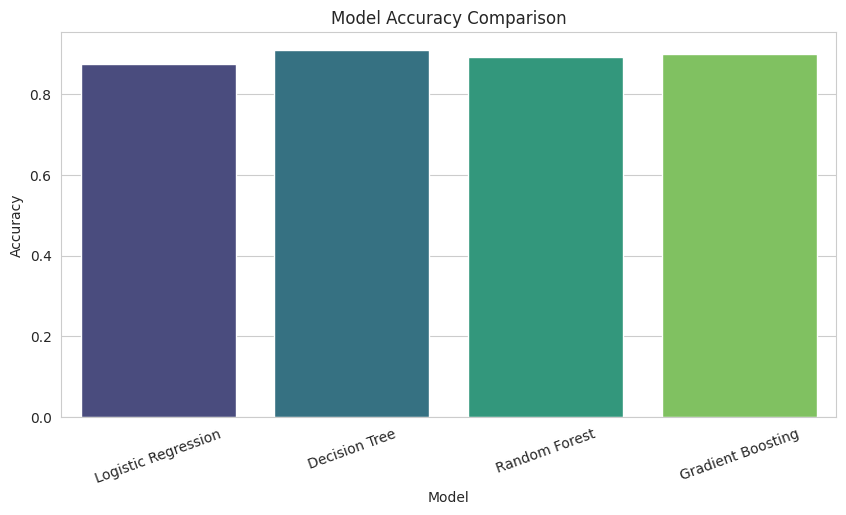

BEST MODEL : Decision Tree


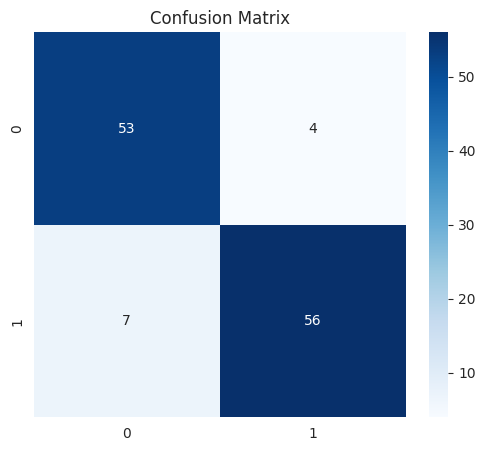

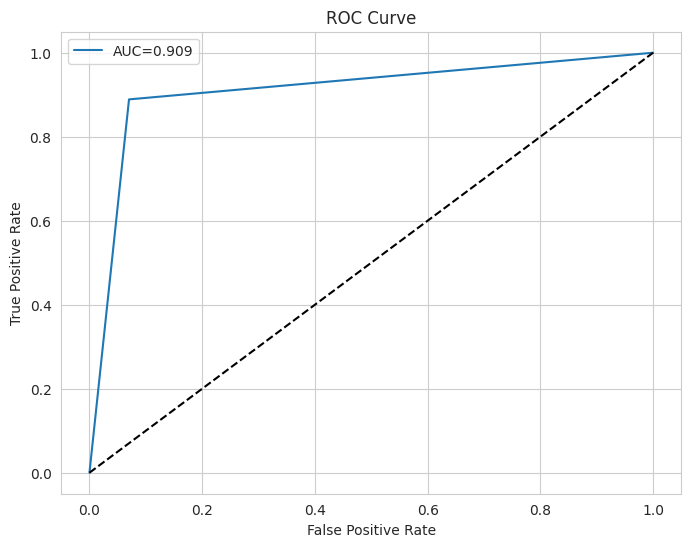

ROC AUC : 0.9094


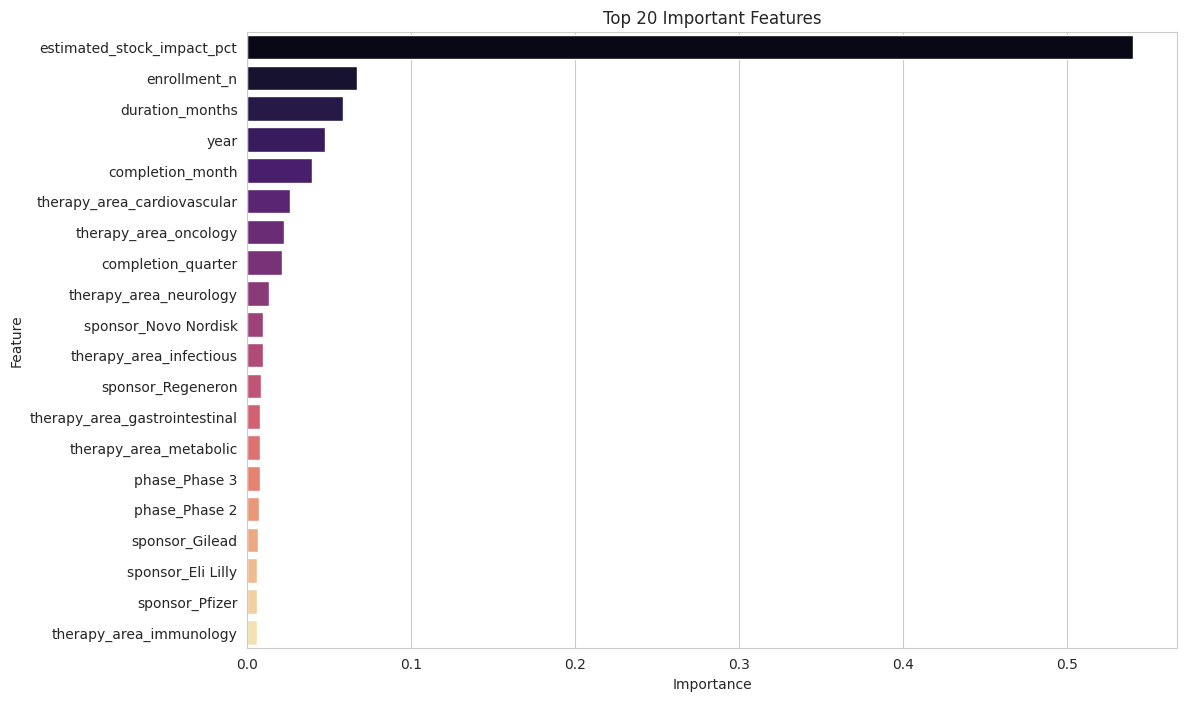


FINAL RESULTS
Logistic Regression  : 0.875
Decision Tree  : 0.9083
Random Forest  : 0.8917
Gradient Boosting  : 0.9
BEST MODEL : Decision Tree
BEST ACCURACY : 0.9083


In [6]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(
"/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/clinical_trials.csv"
)

# ============================================================
# DATE FEATURE ENGINEERING
# ============================================================

df["completion_date"] = pd.to_datetime(
    df["completion_date"],
    errors="coerce"
)

df["completion_month"] = df["completion_date"].dt.month

df["completion_quarter"] = df["completion_date"].dt.quarter

# ============================================================
# TARGET
# ============================================================

target = "is_success"

X = df.drop(columns=[target])

y = df[target]

# ============================================================
# REMOVE LEAKAGE
# ============================================================

X = X.drop(
columns=[
    "trial_id",
    "is_failure",
    "outcome",
    "completion_date"
],
errors="ignore"
)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

# ============================================================
# COLUMN TYPES
# ============================================================

numeric_cols = X_train.select_dtypes(include=np.number).columns

categorical_cols = X_train.select_dtypes(include="object").columns

# ============================================================
# NUMERIC PIPELINE
# ============================================================

numeric_pipeline = Pipeline(

steps=[

("imputer",SimpleImputer(strategy="median")),

("scaler",StandardScaler())

]

)

# ============================================================
# CATEGORICAL PIPELINE
# ============================================================

categorical_pipeline = Pipeline(

steps=[

("imputer",SimpleImputer(strategy="most_frequent")),

("encoder",OneHotEncoder(handle_unknown="ignore"))

]

)

# ============================================================
# PREPROCESSOR
# ============================================================

preprocessor = ColumnTransformer(

transformers=[

("num",numeric_pipeline,numeric_cols),

("cat",categorical_pipeline,categorical_cols)

]

)

# ============================================================
# MODELS
# ============================================================

models = {

"Logistic Regression":
LogisticRegression(max_iter=1000),

"Decision Tree":
DecisionTreeClassifier(random_state=42),

"Random Forest":
RandomForestClassifier(
n_estimators=200,
random_state=42,
n_jobs=-1
),

"Gradient Boosting":
GradientBoostingClassifier(random_state=42)

}

results = {}

trained = {}

# ============================================================
# TRAINING
# ============================================================

for name, model in models.items():

    print("="*60)
    print(name)
    print("="*60)

    pipe = Pipeline(

    steps=[

    ("preprocess",preprocessor),

    ("model",model)

    ]

    )

    pipe.fit(X_train,y_train)

    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test,pred)

    results[name] = acc

    trained[name] = pipe

    print("Accuracy :",round(acc,4))

    print(classification_report(y_test,pred))

# ============================================================
# ACCURACY COMPARISON
# ============================================================

acc_df = pd.DataFrame({

"Model":results.keys(),

"Accuracy":results.values()

})

plt.figure(figsize=(10,5))

sns.barplot(

data=acc_df,

x="Model",

y="Accuracy",

hue="Model",

palette="viridis",

legend=False

)

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_name = max(results,key=results.get)

best_model = trained[best_name]

print("BEST MODEL :",best_name)

# ============================================================
# CONFUSION MATRIX
# ============================================================

pred = best_model.predict(X_test)

plt.figure(figsize=(6,5))

sns.heatmap(

confusion_matrix(y_test,pred),

annot=True,

fmt="d",

cmap="Blues"

)

plt.title("Confusion Matrix")

plt.show()

# ============================================================
# ROC CURVE
# ============================================================

prob = best_model.predict_proba(X_test)[:,1]

fpr,tpr,_ = roc_curve(y_test,prob)

auc = roc_auc_score(y_test,prob)

plt.figure(figsize=(8,6))

plt.plot(fpr,tpr,label=f"AUC={auc:.3f}")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("ROC AUC :",round(auc,4))

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

rf = trained["Random Forest"]

feature_names = (

list(numeric_cols)

+

list(

rf.named_steps["preprocess"]

.named_transformers_["cat"]

.named_steps["encoder"]

.get_feature_names_out(categorical_cols)

)

)

importance = pd.DataFrame({

"Feature":feature_names,

"Importance":rf.named_steps["model"].feature_importances_

})

importance = importance.sort_values(
"Importance",
ascending=False
)

plt.figure(figsize=(12,8))

sns.barplot(

data=importance.head(20),

x="Importance",

y="Feature",

hue="Feature",

palette="magma",

legend=False

)

plt.title("Top 20 Important Features")

plt.show()

# ============================================================
# FINAL RESULT
# ============================================================

print("\nFINAL RESULTS")

print("="*50)

for model,score in results.items():

    print(model," :",round(score,4))

print("="*50)

print("BEST MODEL :",best_name)

print("BEST ACCURACY :",round(max(results.values()),4))

## Thanks......Please Upvote
